# Scribble Simulation Tutorial

Here, we show how to simulate scribbles the same way we will do during the test phase. We also give an example of how to represent the scribbles as Gaussian Heatmaps so you can directly integrate them into your models!

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

import sys
import os

sys.path.append(os.path.abspath(".."))

from simulate_scribbles import (
    scribble_centerline,
    scribble_random,
    scribble_boundary,
    scribbles_to_gc_format,
    simulate_scribble_from_label,
    heatmap_from_coords,
)

def plot_overlay(base, overlay=None, title=""):
    """
    Plot a 2D slice with optional overlay.
    Overlay is highlighted in red.
    """
    plt.imshow(base, cmap="gray")
    
    if overlay is not None:
        # Red overlay with transparency
        red_mask = np.zeros((*overlay.shape, 4), dtype=np.float32)  # RGBA
        red_mask[..., 0] = overlay   # Red channel
        red_mask[..., 3] = overlay * 1.0  # Alpha channel for transparency
        
        plt.imshow(red_mask)
    
    plt.title(title)
    plt.axis("off")

## Load the provided NifTI label

In [2]:
nii_path = "label.nii.gz"

img = nib.load(nii_path)
label = img.get_fdata().astype(np.uint8)

print("Shape:", label.shape)
print("Unique values:", np.unique(label))

Shape: (400, 400, 326)
Unique values: [0 1]


## Pick the slice with the largest area

In [3]:
slice_sums = label.sum(axis=(0, 1))
best_slice = slice_sums.argmax()

slice_mask = label[:, :, best_slice]

print("Using slice:", best_slice)

Using slice: 224


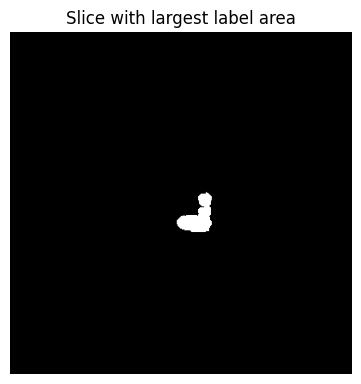

In [4]:
plt.figure(figsize=(15, 10))

# Original mask
plt.subplot(2, 3, 1)
plot_overlay(slice_mask, title="Slice with largest label area")

## Simulate the three types of scribbles

In [5]:
scribble_c, skeleton = scribble_centerline(slice_mask)
scribble_r, _ = scribble_random(slice_mask)
scribble_b, boundary = scribble_boundary(slice_mask)

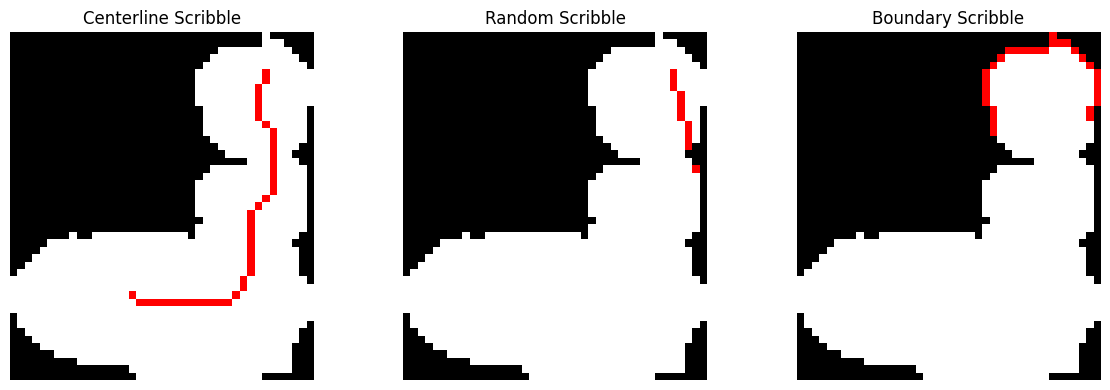

In [6]:
def crop_to_nonzero(base, overlays=[]):
    """
    Crop the 2D array to the bounding box of non-zero elements in base or overlays.
    """
    combined = base.copy()
    for ov in overlays:
        if ov is not None:
            combined = np.maximum(combined, ov)
    
    rows = np.any(combined, axis=1)
    cols = np.any(combined, axis=0)
    
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    
    return base[rmin:rmax+1, cmin:cmax+1], [ov[rmin:rmax+1, cmin:cmax+1] if ov is not None else None for ov in overlays]

# Crop all slices to focus on non-zero region
slice_mask_cropped, [scribble_c_crop, scribble_r_crop, scribble_b_crop] = crop_to_nonzero(
    slice_mask, [scribble_c, scribble_r, scribble_b]
)

# Plot cropped overlays
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plot_overlay(slice_mask_cropped, scribble_c_crop, "Centerline Scribble")

plt.subplot(1, 3, 2)
plot_overlay(slice_mask_cropped, scribble_r_crop, "Random Scribble")

plt.subplot(1, 3, 3)
plot_overlay(slice_mask_cropped, scribble_b_crop, "Boundary Scribble")

plt.tight_layout()
plt.show()

## How does the scribble input look like?
We will provide scribbles in GrandChallenge as lists of 3D coordinates in JSON files. A simple format you can use is a dictionary with keys "tumor" and "background" with the list of scribbles for each class

In [7]:
data = {
    "tumor": [],
    "background": []
}
scribble_coords, fg_class = simulate_scribble_from_label(label, strategy='centerline')

if fg_class:
    data['tumor'] += scribble_coords
else:
    data['background'] += scribble_coords
print(data)

{'tumor': [[229, 192, 224], [229, 193, 224], [228, 194, 224], [228, 195, 224], [228, 196, 224], [228, 197, 224], [228, 198, 224], [229, 199, 224], [230, 200, 224], [230, 201, 224], [230, 202, 224], [230, 203, 224], [230, 204, 224], [230, 205, 224], [230, 206, 224], [230, 207, 224], [230, 208, 224], [229, 209, 224], [228, 210, 224], [227, 211, 224], [227, 212, 224], [227, 213, 224], [227, 214, 224], [227, 215, 224], [227, 216, 224], [227, 217, 224], [227, 218, 224], [227, 219, 224], [226, 220, 224], [226, 221, 224], [211, 222, 224], [225, 222, 224], [212, 223, 224], [213, 223, 224], [214, 223, 224], [215, 223, 224], [216, 223, 224], [217, 223, 224], [218, 223, 224], [219, 223, 224], [220, 223, 224], [221, 223, 224], [222, 223, 224], [223, 223, 224], [224, 223, 224]], 'background': []}


### In GrandChallenge, these scribbles will look like this in the JSON file due to their interface
We provide utility functions to convert back and forth from Grand Challenge and the simple interface in our scribble_simulation.py script. Check it out!

In [8]:
gc_dict = scribbles_to_gc_format(data)
print(gc_dict)

{'version': {'major': 1, 'minor': 0}, 'type': 'Multiple points', 'points': [{'point': [229, 192, 224], 'name': 'tumor'}, {'point': [229, 193, 224], 'name': 'tumor'}, {'point': [228, 194, 224], 'name': 'tumor'}, {'point': [228, 195, 224], 'name': 'tumor'}, {'point': [228, 196, 224], 'name': 'tumor'}, {'point': [228, 197, 224], 'name': 'tumor'}, {'point': [228, 198, 224], 'name': 'tumor'}, {'point': [229, 199, 224], 'name': 'tumor'}, {'point': [230, 200, 224], 'name': 'tumor'}, {'point': [230, 201, 224], 'name': 'tumor'}, {'point': [230, 202, 224], 'name': 'tumor'}, {'point': [230, 203, 224], 'name': 'tumor'}, {'point': [230, 204, 224], 'name': 'tumor'}, {'point': [230, 205, 224], 'name': 'tumor'}, {'point': [230, 206, 224], 'name': 'tumor'}, {'point': [230, 207, 224], 'name': 'tumor'}, {'point': [230, 208, 224], 'name': 'tumor'}, {'point': [229, 209, 224], 'name': 'tumor'}, {'point': [228, 210, 224], 'name': 'tumor'}, {'point': [227, 211, 224], 'name': 'tumor'}, {'point': [227, 212, 224

## How do we integrate scribbles into our model?
A very simple and often adopted approach is to represent the scribbles as Gaussian heatmaps. These can be then concatenated with the image input or fed in any way to your models (input-level, post-processing, even in the bottleneck features). This is still an open research question. Here is how to get those heatmaps! (We also use heatmaps for our baseline model!)

In [9]:
heatmap = heatmap_from_coords(data['tumor'], label.shape, sigma=0)

print(heatmap.shape)

(400, 400, 326)


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import imageio
from io import BytesIO
from PIL import Image
import os

def create_rotating_gif(heatmap, filename="heatmap_rotating.gif", frames=60, sigma=1, threshold=0.01):
    """
    Create a rotating GIF of a 3D heatmap with smooth Gaussian spheres.
    GIF will loop infinitely.
    """
    # Extract coordinates above threshold
    x, y, z = np.nonzero(heatmap > threshold)
    values = heatmap[x, y, z]

    images = []

    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d', facecolor='black')

    for i in range(frames):
        ax.cla()
        ax.scatter(x, y, z, c=values, cmap=plt.cm.hot_r, s=20, alpha=0.6)
        ax.set_xlim(0, heatmap.shape[0])
        ax.set_ylim(0, heatmap.shape[1])
        ax.set_zlim(0, heatmap.shape[2])
        ax.axis('off')

        # Rotate
        angle = i * 360 / frames
        ax.view_init(elev=30, azim=angle)

        # Save figure to buffer
        buf = BytesIO()
        fig.savefig(buf, format='png', dpi=80, bbox_inches='tight', pad_inches=0, facecolor='black')
        buf.seek(0)
        img = Image.open(buf).convert("RGBA")
        images.append(img)
        buf.close()

    plt.close(fig)

    # Save as GIF with infinite loop
    images[0].save(
        filename,
        save_all=True,
        append_images=images[1:],
        duration=100,  # milliseconds per frame
        loop=0  # 0 = infinite looping
    )

    print(f"Saved rotating GIF to {filename}")

# Example usage
create_rotating_gif(heatmap, filename="scribble.gif", frames=60, sigma=1, threshold=0.01)

if not os.path.exists('label.gif'):
    create_rotating_gif(label, filename="label.gif", frames=60, sigma=1, threshold=0.01)

from IPython.display import display, HTML

display(HTML("""
<div style="display: flex; align-items: center;">
    <div style="margin-right: 10px;">
        <h4>Scribble Heatmap</h4>
        <img src="scribble.gif" width="300" loop="infinite">
    </div>
    <div>
        <h4>Label</h4>
        <img src="label.gif" width="300" loop="infinite">
    </div>
</div>
"""))

Saved rotating GIF to scribble.gif


## How We Simulate Scribbles During Testing

During the **test phase**, scribbles are simulated **iteratively** based on your model’s errors:

1. **First scribble:** Simulated exactly as in this tutorial -> using the **ground-truth label**.  
2. **Additional scribbles:** Up to **4 more scribbles** are generated based on the model’s errors:  
   - **Oversegmentation:** If the largest error component is an **oversegmentation**, we simulate a **background scribble**.  
   - **Undersegmentation:** If the largest error component is an **undersegmentation**, we simulate a **foreground scribble**.  

This iterative approach allows the model to receive scribbles that highlight its mistakes, mimicking a realistic interactive refinement process. The 

For full implementation details, see the [`interactive_loop.py`](../interactive_loop.py) script.